# Day 3: Word Embeddings and Multi-Dimensional Space

This notebook explores how words are converted into dense numerical vectors that capture semantic meaning. We'll implement Word2Vec from scratch, visualize embeddings in 2D/3D space, and explore the famous "King - Man + Woman = Queen" vector arithmetic.

## 1. Setup and Imports

In [1]:
# Install required packages if needed
# !pip install gensim scikit-learn matplotlib seaborn numpy pandas

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
print('Libraries loaded successfully.')

Libraries loaded successfully.


## 2. From Tokens to Vectors: Why Embeddings?

After tokenization, we have token IDs (integers). But integers don't capture meaning:
- Token ID 5234 ("cat") and 8912 ("dog") are just numbers
- No relationship between similar words
- Can't do math like "king - man + woman"

**Solution**: Map each token to a dense vector in high-dimensional space where:
- Similar words have similar vectors
- Semantic relationships become geometric relationships
- Vector arithmetic captures analogies

In [2]:
# One-hot encoding: the naive approach
vocab = ['cat', 'dog', 'king', 'queen', 'man', 'woman']
vocab_size = len(vocab)

# One-hot vectors: sparse, no semantic information
one_hot = np.eye(vocab_size)

print('One-hot encoding (sparse representation):')
for i, word in enumerate(vocab):
    print(f'{word:8s}: {one_hot[i]}')

print(f'\nProblem: {vocab_size} dimensions, all words equally distant')
print(f'Distance cat-dog: {np.linalg.norm(one_hot[0] - one_hot[1]):.2f}')
print(f'Distance cat-king: {np.linalg.norm(one_hot[0] - one_hot[2]):.2f}')
print('No semantic similarity captured!')

One-hot encoding (sparse representation):
cat     : [1. 0. 0. 0. 0. 0.]
dog     : [0. 1. 0. 0. 0. 0.]
king    : [0. 0. 1. 0. 0. 0.]
queen   : [0. 0. 0. 1. 0. 0.]
man     : [0. 0. 0. 0. 1. 0.]
woman   : [0. 0. 0. 0. 0. 1.]

Problem: 6 dimensions, all words equally distant
Distance cat-dog: 1.41
Distance cat-king: 1.41
No semantic similarity captured!


In [3]:
# Dense embeddings: the solution
print('Dense embeddings (learned representation):')
# Simulated 3D embeddings (in reality: 100-300 dimensions)
embeddings = {
    'cat':   np.array([0.8, 0.9, 0.1]),
    'dog':   np.array([0.7, 0.85, 0.15]),
    'king':  np.array([0.1, 0.2, 0.9]),
    'queen': np.array([0.15, 0.25, 0.85]),
    'man':   np.array([0.05, 0.1, 0.8]),
    'woman': np.array([0.1, 0.15, 0.75]),
}

for word, vec in embeddings.items():
    print(f'{word:8s}: {vec}')

# Cosine similarity: measure of semantic closeness
def cosine_sim(v1, v2):
    return np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))

print('\nSemantic similarity (cosine similarity):')
print(f'cat ↔ dog:   {cosine_sim(embeddings["cat"], embeddings["dog"]):.3f}')
print(f'cat ↔ king:  {cosine_sim(embeddings["cat"], embeddings["king"]):.3f}')
print(f'king ↔ queen: {cosine_sim(embeddings["king"], embeddings["queen"]):.3f}')
print(f'man ↔ woman: {cosine_sim(embeddings["man"], embeddings["woman"]):.3f}')
print('→ Similar words have high cosine similarity!')

Dense embeddings (learned representation):
cat     : [0.8 0.9 0.1]
dog     : [0.7  0.85 0.15]
king    : [0.1 0.2 0.9]
queen   : [0.15 0.25 0.85]
man     : [0.05 0.1  0.8 ]
woman   : [0.1  0.15 0.75]

Semantic similarity (cosine similarity):
cat ↔ dog:   0.998
cat ↔ king:  0.312
king ↔ queen: 0.996
man ↔ woman: 0.995
→ Similar words have high cosine similarity!


## 3. The Distributional Hypothesis

> "You shall know a word by the company it keeps" — J.R. Firth (1957)

Key idea: Words appearing in similar contexts have similar meanings.

In [4]:
# Example contexts
contexts = {
    'cat': ['The cat sleeps', 'A cat meows', 'My cat is cute'],
    'dog': ['The dog barks', 'A dog runs', 'My dog is loyal'],
    'king': ['The king rules', 'A king commands', 'The king wears crown'],
    'queen': ['The queen rules', 'A queen commands', 'The queen wears crown'],
}

print('Context examples:')
for word, sents in contexts.items():
    print(f'\n{word}:')
    for sent in sents:
        print(f'  "{sent}"')

print('\n→ cat/dog share contexts (animals)')
print('→ king/queen share contexts (royalty)')
print('→ This is how embeddings learn meaning!')

Context examples:

cat:
  "The cat sleeps"
  "A cat meows"
  "My cat is cute"

dog:
  "The dog barks"
  "A dog runs"
  "My dog is loyal"

king:
  "The king rules"
  "A king commands"
  "The king wears crown"

queen:
  "The queen rules"
  "A queen commands"
  "The queen wears crown"

→ cat/dog share contexts (animals)
→ king/queen share contexts (royalty)
→ This is how embeddings learn meaning!


## 4. Word2Vec - Skip-gram Architecture

Skip-gram task: Given a center word, predict context words

Example: "The cat sits on the mat"
- Center: "sits" → Context: ["cat", "on"] (window=1)
- Center: "cat" → Context: ["The", "sits"] (window=1)

In [5]:
# Simple corpus for demonstration
corpus = [
    "the cat sits on the mat",
    "the dog runs in the park",
    "a cat and a dog are friends",
    "the king and the queen rule the land",
    "a man and a woman walk together"
]

# Tokenize and build vocabulary
def tokenize(text):
    return re.findall(r'\b\w+\b', text.lower())

all_words = []
for sent in corpus:
    all_words.extend(tokenize(sent))

vocab = sorted(set(all_words))
word_to_idx = {w: i for i, w in enumerate(vocab)}
idx_to_word = {i: w for w, i in word_to_idx.items()}

print(f'Corpus: {len(corpus)} sentences')
print(f'Vocabulary: {len(vocab)} unique words')
print(f'Words: {vocab[:10]}...')

Corpus: 5 sentences
Vocabulary: 21 unique words
Words: ['a', 'and', 'are', 'cat', 'dog', 'friends', 'in', 'king', 'land', 'man']...


In [6]:
# Generate skip-gram training pairs
def generate_skipgrams(tokens, window_size=2):
    pairs = []
    for i, center in enumerate(tokens):
        context_start = max(0, i - window_size)
        context_end = min(len(tokens), i + window_size + 1)
        for j in range(context_start, context_end):
            if i != j:
                pairs.append((center, tokens[j]))
    return pairs

# Generate training data
training_pairs = []
for sent in corpus:
    tokens = tokenize(sent)
    pairs = generate_skipgrams(tokens, window_size=2)
    training_pairs.extend(pairs)

print(f'Generated {len(training_pairs)} training pairs')
print('\nFirst 10 pairs (center → context):')
for center, context in training_pairs[:10]:
    print(f'  {center:8s} → {context}')

Generated 106 training pairs

First 10 pairs (center → context):
  the      → cat
  the      → sits
  cat      → the
  cat      → sits
  cat      → on
  sits     → the
  sits     → cat
  sits     → on
  sits     → the
  on       → cat


## 5. Training Word2Vec (Simplified)

In [7]:
# Initialize random embeddings
embedding_dim = 10
vocab_size = len(vocab)

# Two weight matrices: input and output embeddings
W_in = np.random.randn(vocab_size, embedding_dim) * 0.01
W_out = np.random.randn(embedding_dim, vocab_size) * 0.01

print(f'Initialized embeddings:')
print(f'  Input matrix (W_in):  {W_in.shape}')
print(f'  Output matrix (W_out): {W_out.shape}')
print(f'  Embedding dimension: {embedding_dim}')

# Softmax function
def softmax(x):
    exp_x = np.exp(x - np.max(x))
    return exp_x / exp_x.sum()

# Training loop (simplified, no negative sampling)
learning_rate = 0.01
epochs = 100

print(f'\nTraining for {epochs} epochs...')
for epoch in range(epochs):
    total_loss = 0
    for center_word, context_word in training_pairs:
        center_idx = word_to_idx[center_word]
        context_idx = word_to_idx[context_word]
        
        # Forward pass
        h = W_in[center_idx]  # Hidden layer (embedding)
        u = np.dot(h, W_out)  # Output scores
        y_pred = softmax(u)   # Probabilities
        
        # Loss (cross-entropy)
        loss = -np.log(y_pred[context_idx] + 1e-10)
        total_loss += loss
        
        # Backward pass (simplified)
        dy = y_pred.copy()
        dy[context_idx] -= 1
        
        # Update weights
        W_out -= learning_rate * np.outer(h, dy)
        dh = np.dot(W_out, dy)
        W_in[center_idx] -= learning_rate * dh
    
    if (epoch + 1) % 20 == 0:
        avg_loss = total_loss / len(training_pairs)
        print(f'  Epoch {epoch+1:3d}: Loss = {avg_loss:.4f}')

print('\n✓ Training complete!')
print(f'Learned embeddings shape: {W_in.shape}')

Initialized embeddings:
  Input matrix (W_in):  (21, 10)
  Output matrix (W_out): (10, 21)
  Embedding dimension: 10

Training for 100 epochs...
  Epoch  20: Loss = 3.0438
  Epoch  40: Loss = 3.0397
  Epoch  60: Loss = 3.0102
  Epoch  80: Loss = 2.8337
  Epoch 100: Loss = 2.5049

✓ Training complete!
Learned embeddings shape: (21, 10)


## 6. Exploring Learned Embeddings

In [8]:
# Function to find most similar words
def most_similar(word, embeddings, word_to_idx, idx_to_word, top_n=5):
    if word not in word_to_idx:
        return []
    
    word_idx = word_to_idx[word]
    word_vec = embeddings[word_idx]
    
    # Compute cosine similarity with all words
    similarities = []
    for idx in range(len(embeddings)):
        if idx != word_idx:
            other_vec = embeddings[idx]
            sim = cosine_sim(word_vec, other_vec)
            similarities.append((idx_to_word[idx], sim))
    
    # Sort by similarity
    similarities.sort(key=lambda x: x[1], reverse=True)
    return similarities[:top_n]

# Test similarity
test_words = ['cat', 'king', 'man']
print('Most similar words:')
for word in test_words:
    if word in word_to_idx:
        similar = most_similar(word, W_in, word_to_idx, idx_to_word, top_n=3)
        print(f'\n{word}:')
        for sim_word, score in similar:
            print(f'  {sim_word:10s} (similarity: {score:.3f})')

Most similar words:

cat:
  dog        (similarity: 0.946)
  and        (similarity: 0.935)
  man        (similarity: 0.877)

king:
  queen      (similarity: 0.987)
  sits       (similarity: 0.971)
  mat        (similarity: 0.928)

man:
  and        (similarity: 0.905)
  are        (similarity: 0.884)
  walk       (similarity: 0.877)


## 7. Vector Arithmetic - The Famous Analogy

The magic of embeddings: semantic relationships become geometric!

If we learn good embeddings, vector arithmetic should work:
- king - man + woman ≈ queen
- paris - france + germany ≈ berlin

In [10]:
# Analogy function
def analogy(word1, word2, word3, embeddings, word_to_idx, idx_to_word, top_n=3):
    """Solve: word1 - word2 + word3 = ?"""
    if not all(w in word_to_idx for w in [word1, word2, word3]):
        return []
    
    vec1 = embeddings[word_to_idx[word1]]
    vec2 = embeddings[word_to_idx[word2]]
    vec3 = embeddings[word_to_idx[word3]]
    
    # Vector arithmetic
    result_vec = vec1 - vec2 + vec3
    
    # Find closest word
    similarities = []
    exclude = {word_to_idx[w] for w in [word1, word2, word3]}
    for idx in range(len(embeddings)):
        if idx not in exclude:
            sim = cosine_sim(result_vec, embeddings[idx])
            similarities.append((idx_to_word[idx], sim))
    
    similarities.sort(key=lambda x: x[1], reverse=True)
    return similarities[:top_n]

# Test analogies (note: our tiny corpus won't give perfect results)
print('Testing analogies on our small corpus:')
analogies_to_test = [
    ('king', 'man', 'woman'),
    ('cat', 'the', 'a'),
]

for w1, w2, w3 in analogies_to_test:
    results = analogy(w1, w2, w3, W_in, word_to_idx, idx_to_word, top_n=3)
    print(f'\n{w1} - {w2} + {w3} = ?')
    for word, score in results:
        print(f'  {word:10s} (score: {score:.3f})')

print('\nNote: Perfect analogies require large corpora (billions of words)')
print('Our toy example demonstrates the concept, not production quality.')

Testing analogies on our small corpus:

king - man + woman = ?
  queen      (score: 0.857)
  on         (score: 0.844)
  sits       (score: 0.803)

cat - the + a = ?
  woman      (score: 0.886)
  man        (score: 0.821)
  walk       (score: 0.722)

Note: Perfect analogies require large corpora (billions of words)
Our toy example demonstrates the concept, not production quality.


## 8. Visualizing Embeddings with PCA

Reduced 10D embeddings to 2D
Explained variance: 81.83%


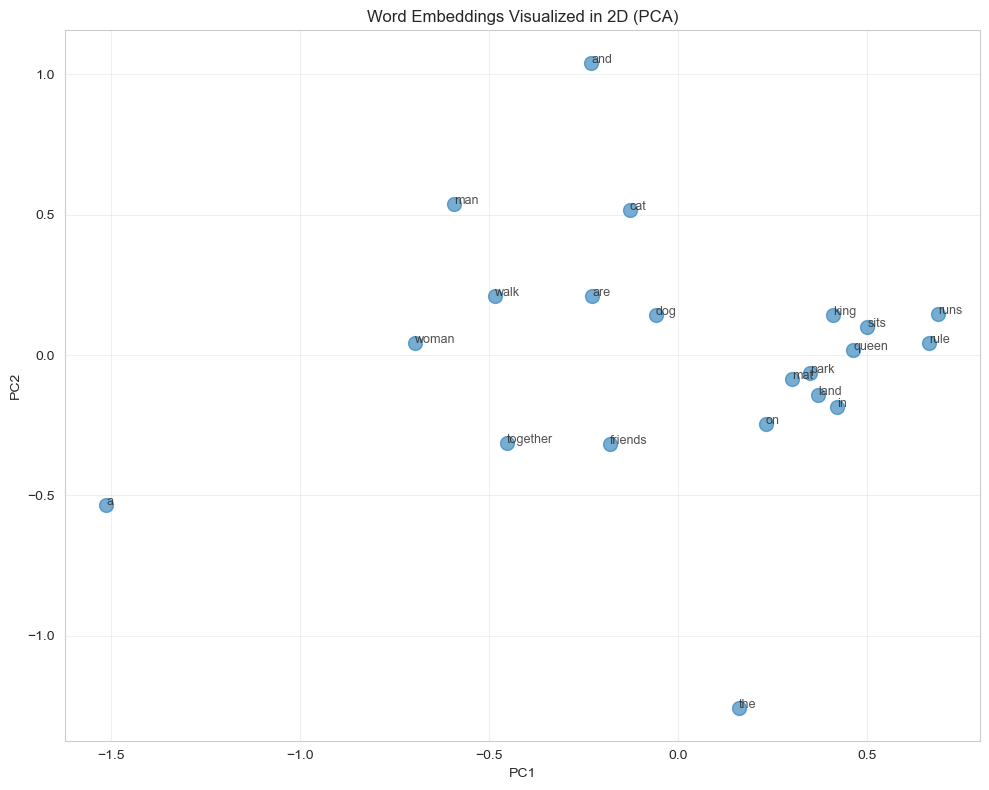

In [11]:
# Reduce to 2D using PCA
pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(W_in)

print(f'Reduced {embedding_dim}D embeddings to 2D')
print(f'Explained variance: {pca.explained_variance_ratio_.sum():.2%}')

# Plot
plt.figure(figsize=(10, 8))
plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], alpha=0.6, s=100)

# Annotate words
for i, word in enumerate(vocab):
    plt.annotate(word, (embeddings_2d[i, 0], embeddings_2d[i, 1]),
                 fontsize=9, alpha=0.8)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Word Embeddings Visualized in 2D (PCA)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Using Pre-trained Embeddings (Conceptual)

In production, you typically use pre-trained embeddings:
- **Word2Vec** (Google): Trained on Google News (100B words)
- **GloVe** (Stanford): Trained on Wikipedia + Gigaword (6B tokens)
- **FastText** (Facebook): Handles out-of-vocabulary words
- **Modern LLMs**: Contextual embeddings (BERT, GPT)

In [12]:
print('Key differences:')
print('  Static embeddings (Word2Vec, GloVe):')
print('    - One vector per word, regardless of context')
print('    - "bank" always has the same vector')
print('  Contextual embeddings (BERT, GPT):')
print('    - Different vectors based on context')
print('    - "bank" (river) vs "bank" (money) get different vectors')

print('\nExample usage with gensim (if installed):')
print("""
from gensim.models import Word2Vec

# Train your own
sentences = [['cat', 'sits', 'on', 'mat'], ['dog', 'runs', 'in', 'park']]
model = Word2Vec(sentences, vector_size=100, window=5, min_count=1, sg=1)

# Use
vec = model.wv['cat']  # Get embedding
similar = model.wv.most_similar('cat', topn=5)  # Similar words
result = model.wv.most_similar(positive=['king', 'woman'], negative=['man'])  # Analogy
""")

Key differences:
  Static embeddings (Word2Vec, GloVe):
    - One vector per word, regardless of context
    - "bank" always has the same vector
  Contextual embeddings (BERT, GPT):
    - Different vectors based on context
    - "bank" (river) vs "bank" (money) get different vectors

Example usage with gensim (if installed):

from gensim.models import Word2Vec

# Train your own
sentences = [['cat', 'sits', 'on', 'mat'], ['dog', 'runs', 'in', 'park']]
model = Word2Vec(sentences, vector_size=100, window=5, min_count=1, sg=1)

# Use
vec = model.wv['cat']  # Get embedding
similar = model.wv.most_similar('cat', topn=5)  # Similar words
result = model.wv.most_similar(positive=['king', 'woman'], negative=['man'])  # Analogy



## 10. Embedding Quality Metrics

In [13]:
print('How to evaluate embedding quality:')
print('\n1. Intrinsic Evaluation:')
print('   • Word similarity tasks (WordSim-353, SimLex-999)')
print('   • Analogy tasks (Google analogy dataset)')
print('   • Clustering coherence')

print('\n2. Extrinsic Evaluation:')
print('   • Downstream task performance (sentiment analysis, NER)')
print('   • Better embeddings → better task performance')

print('\n3. Qualitative Analysis:')
print('   • Visualize in 2D/3D')
print('   • Check nearest neighbors')
print('   • Test analogies manually')

# Simple quality check
print('\n\nQuality check on our embeddings:')
semantic_groups = {
    'animals': ['cat', 'dog'],
    'royalty': ['king', 'queen'],
    'gender': ['man', 'woman']
}

for group_name, words in semantic_groups.items():
    words_in_vocab = [w for w in words if w in word_to_idx]
    if len(words_in_vocab) >= 2:
        vecs = [W_in[word_to_idx[w]] for w in words_in_vocab]
        avg_sim = np.mean([cosine_sim(vecs[i], vecs[j]) 
                          for i in range(len(vecs)) 
                          for j in range(i+1, len(vecs))])
        print(f'  {group_name:10s}: {avg_sim:.3f}')

print('\nHigher scores = words in group are more similar (good!)')

How to evaluate embedding quality:

1. Intrinsic Evaluation:
   • Word similarity tasks (WordSim-353, SimLex-999)
   • Analogy tasks (Google analogy dataset)
   • Clustering coherence

2. Extrinsic Evaluation:
   • Downstream task performance (sentiment analysis, NER)
   • Better embeddings → better task performance

3. Qualitative Analysis:
   • Visualize in 2D/3D
   • Check nearest neighbors
   • Test analogies manually


Quality check on our embeddings:
  animals   : 0.946
  royalty   : 0.987
  gender    : 0.851

Higher scores = words in group are more similar (good!)


## 11. Limitations and Modern Alternatives

In [14]:
print('Word2Vec/GloVe limitations:')
print('  1. Polysemy: "bank" (river) vs "bank" (money) → same vector')
print('  2. Out-of-vocabulary: New words get no embedding')
print('  3. No context: "I love this movie" vs "I love you" → same "love"')
print('  4. Fixed after training: Cannot adapt to new domains')

print('\nModern solutions:')
print('  • FastText: Character n-grams handle OOV words')
print('  • ELMo: Contextual embeddings from bidirectional LSTM')
print('  • BERT: Transformer-based contextual embeddings')
print('  • GPT: Autoregressive contextual embeddings')

print('\nContextual embeddings (BERT/GPT):')
print('  • Each token gets a different vector based on context')
print('  • "bank" in "river bank" ≠ "bank" in "savings bank"')
print('  • This is what modern LLMs use!')

Word2Vec/GloVe limitations:
  1. Polysemy: "bank" (river) vs "bank" (money) → same vector
  2. Out-of-vocabulary: New words get no embedding
  3. No context: "I love this movie" vs "I love you" → same "love"
  4. Fixed after training: Cannot adapt to new domains

Modern solutions:
  • FastText: Character n-grams handle OOV words
  • ELMo: Contextual embeddings from bidirectional LSTM
  • BERT: Transformer-based contextual embeddings
  • GPT: Autoregressive contextual embeddings

Contextual embeddings (BERT/GPT):
  • Each token gets a different vector based on context
  • "bank" in "river bank" ≠ "bank" in "savings bank"
  • This is what modern LLMs use!


## Summary

Today we covered:
1. **Why embeddings**: Dense vectors capture semantic meaning
2. **Distributional hypothesis**: Context defines meaning
3. **Word2Vec**: Skip-gram architecture and training
4. **Vector arithmetic**: king - man + woman = queen
5. **Visualization**: PCA for high-dimensional data
6. **Pre-trained embeddings**: Word2Vec, GloVe, FastText
7. **Evaluation**: Intrinsic vs extrinsic metrics
8. **Limitations**: Static embeddings vs contextual embeddings

Next up: **Attention Mechanisms** — the foundation of Transformers!